In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7242J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7052J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4492G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4821G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4742E0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4472F0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4822G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7241J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4061E0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig

In [2]:
import pandas as pd
import os

# Read the CSV file (replace 'input.csv' with your actual filename)
df = pd.read_csv('/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv')

# Add tensor_path column: basepath + new prefix + _spectral.pt
def create_spectral_path(filename):
    base_name = filename.split('\\')[-1][:-3]  # Get filename without extension
    new_path = f"/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/{base_name}_spectral.pt"
    return new_path

def create_raw_path(filename):
    base_name = filename.split('\\')[-1][:-3]  # Get filename without extension
    new_path = f'/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/tensors/{base_name}.pt'
    return new_path

# Assuming there's a column with original paths/filenames (adjust column name as needed)
df['spectral'] = df['tensor_path'].apply(create_spectral_path)  # Replace 'path_column' with actual column
df['tensor_path'] = df['tensor_path'].apply(create_raw_path)
# Create/modify spectral column (example - adjust logic as needed)
# df['spectral'] = df['tensor_path']  # Or whatever transformation you need

# Save modified CSV
df.to_csv('output.csv', index=False)
print("Modified CSV saved as 'output.csv'")
print(df[['tensor_path', 'spectral']].head())


Modified CSV saved as 'output.csv'
                                         tensor_path  \
0  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
1  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
2  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
3  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
4  /kaggle/input/datasets/girishgiriirig/sleep-ed...   

                                            spectral  
0  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
1  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
2  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
3  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
4  /kaggle/input/datasets/girishgiriirig/sleep-ed...  


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import time
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    cohen_kappa_score, confusion_matrix
)
import json
from sklearn.model_selection import train_test_split

# Ablation: Spectral-Only Sleep Staging

This notebook removes the temporal CNN branch entirely. The model uses only the MLP spectral encoder → Transformer pipeline. No raw EEG tensors are loaded or processed.

In [4]:
STAGE_TO_IDX = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4
}

IDX_TO_STAGE = {v: k for k, v in STAGE_TO_IDX.items()}
NUM_CLASSES = 5


class SpectralOnlySleepDataset(Dataset):
    """
    Ablation dataset — loads ONLY spectral feature tensors.
    Raw EEG / temporal tensors are not loaded at all.

        x_spectral : [W, 34]
        y          : [W]
    """

    def __init__(self, csv_path, file_indices=None, window_size=256, overlap=0):
        assert overlap < window_size, "overlap must be < window_size"

        self.df = pd.read_csv(csv_path)
        if file_indices is not None:
            self.df = self.df.iloc[file_indices].reset_index(drop=True)

        self.window_size = window_size
        self.stride      = window_size - overlap

        self.index = []
        for row_idx, row in self.df.iterrows():
            T = len(row['stage_sequence'].split(' '))
            start = 0
            while start < T:
                self.index.append((row_idx, start))
                start += self.stride

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        row_idx, start = self.index[idx]
        row = self.df.iloc[row_idx]
        end = start + self.window_size

        x_spectral = torch.load(row['spectral']).float()[start:end]  # [W, 34]

        stages = row['stage_sequence'].split(' ')[start:end]
        y = torch.tensor([STAGE_TO_IDX[s] for s in stages], dtype=torch.long)

        return x_spectral, y


In [5]:
def spectral_collate_fn(batch):
    """
    Collates a batch of (x_spectral, y) tuples.
    Returns:
        x_spec       : [B, T_max, 34]
        y_padded     : [B, T_max]        — padded with -100
        padding_mask : [B, T_max] bool   — True where padded
    """
    lengths  = [xs.shape[0] for xs, _ in batch]
    max_len  = max(lengths)
    B        = len(batch)
    spec_dim = batch[0][0].shape[1]   # 34

    x_spec   = torch.zeros(B, max_len, spec_dim)
    y_padded = torch.full((B, max_len), -100, dtype=torch.long)
    pad_mask = torch.ones(B, max_len, dtype=torch.bool)

    for i, (xs, y) in enumerate(batch):
        T = xs.shape[0]
        x_spec[i,   :T] = xs
        y_padded[i, :T] = y
        pad_mask[i, :T] = False

    return x_spec, y_padded, pad_mask


In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SleepTransformer(nn.Module):
    def __init__(self, embed_dim=128, heads=4, layers=4, dropout=0.2, max_len=512):
        super().__init__()
        self.positional_encoding = PositionalEncoding(embed_dim, max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads,
            dim_feedforward=embed_dim * 4, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.cls     = nn.Linear(embed_dim, NUM_CLASSES)

    def forward(self, x, padding_mask=None):
        x = self.positional_encoding(x)
        h = self.encoder(x, src_key_padding_mask=padding_mask)
        return self.cls(h)


# ── Ablation: Spectral-Only model ────────────────────────────────────────────
class SpectralOnlySleepStagingModel(nn.Module):
    """
    Ablation model — no temporal CNN, no fusion.
    Pipeline: MLP spectral encoder → SleepTransformer → classification.

    The spectral MLP mirrors the encoder used in the full fusion model.
    Returns (logits, aux_logits) — aux mirrors main for training-loop compat.
    """
    def __init__(self, spectral_input_dim=34, embed_dim=128,
                 heads=4, layers=6, dropout=0.2):
        super().__init__()
        self.spectral_encoder = nn.Sequential(
            nn.Linear(spectral_input_dim, 128), nn.GELU(), nn.LayerNorm(128),
            nn.Linear(128, embed_dim),          nn.GELU(), nn.LayerNorm(embed_dim),
        )
        self.context = SleepTransformer(
            embed_dim=embed_dim, heads=heads,
            layers=layers, dropout=dropout
        )

    def forward(self, x_spec, padding_mask=None):
        feats  = self.spectral_encoder(x_spec)   # [B, T, embed_dim]
        logits = self.context(feats, padding_mask)
        return logits, logits   # aux mirrors main


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, num_classes=5):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.register_buffer('alpha', torch.ones(num_classes))
        else:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))

    def forward(self, logits, targets):
        valid   = targets != -100
        logits  = logits[valid]
        targets = targets[valid]
        if logits.numel() == 0:
            return logits.sum() * 0.0
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_specificity(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specs.append(tn / (tn + fp + 1e-8))
    return float(np.mean(specs))


def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy":     accuracy_score(y_true, y_pred),
        "f1_weighted":  f1_score(y_true, y_pred, average="weighted"),
        "f1_macro":     f1_score(y_true, y_pred, average="macro"),
        "precision":    precision_score(y_true, y_pred, average="weighted"),
        "recall":       recall_score(y_true, y_pred, average="weighted"),
        "kappa":        cohen_kappa_score(y_true, y_pred),
        "specificity":  compute_specificity(y_true, y_pred)
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
        metrics["pr_auc"]  = average_precision_score(y_true, y_prob, average="weighted")
    except ValueError:
        metrics["roc_auc"] = None
        metrics["pr_auc"]  = None
    return metrics


def logger(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")


In [8]:
def evaluate_spectral(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    use_amp = device.type == 'cuda'

    with torch.no_grad():
        for x_spec, y, padding_mask in loader:
            x_spec       = x_spec.to(device)
            y            = y.to(device)
            padding_mask = padding_mask.to(device)

            with torch.amp.autocast(device_type='cuda', enabled=use_amp):
                logits, _ = model(x_spec, padding_mask)

            probs = torch.softmax(logits, dim=-1)
            preds = probs.argmax(dim=-1)
            valid = ~padding_mask

            y_true.extend(y[valid].cpu().numpy())
            y_pred.extend(preds[valid].cpu().numpy())
            y_prob.extend(probs[valid].cpu().numpy())

    return compute_metrics(np.array(y_true), np.array(y_pred), np.array(y_prob))


def train_model_spectral(train_dataset, val_dataset, device, epochs=150):

    train_loader = DataLoader(
        train_dataset, batch_size=16, shuffle=True,
        num_workers=2, collate_fn=spectral_collate_fn,
        pin_memory=True, persistent_workers=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=16, shuffle=False,
        num_workers=2, collate_fn=spectral_collate_fn,
        pin_memory=True, persistent_workers=True
    )

    model = nn.DataParallel(SpectralOnlySleepStagingModel()).to(device)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger(f"Spectral-Only model on {device}")
    logger(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")
    logger(f"Train chunks: {len(train_dataset):,} | Val chunks: {len(val_dataset):,}")

    class_counts  = torch.tensor([70154, 25175, 88983, 19454, 34184], dtype=torch.float)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)
    AUX_WEIGHT = 0.3

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05
    )
    scaler  = torch.amp.GradScaler()
    best_f1 = -1

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (x_spec, y, padding_mask) in enumerate(train_loader):
            x_spec       = x_spec.to(device)
            y            = y.to(device)
            padding_mask = padding_mask.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                logits, aux_logits = model(x_spec, padding_mask)
                y_flat    = y.view(-1)
                loss_main = criterion(logits.view(-1, NUM_CLASSES), y_flat)
                loss_aux  = criterion(aux_logits.view(-1, NUM_CLASSES), y_flat)
                loss      = loss_main + AUX_WEIGHT * loss_aux

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            if device.type == 'cuda' and batch_idx % 50 == 0:
                mem_alloc    = torch.cuda.memory_allocated() / 1024**2
                mem_reserved = torch.cuda.memory_reserved() / 1024**2
                print(f"  GPU | Alloc: {mem_alloc:.1f} MB | Reserved: {mem_reserved:.1f} MB")

            total_loss += loss.item()

        metrics = evaluate_spectral(model, val_loader, device)

        log = {'epoch': epoch, 'train_loss': total_loss / len(train_loader), **metrics}
        with open('/kaggle/working/training_metrics_spectral_only.jsonl', 'a') as f:
            f.write(json.dumps(log) + '\n')

        if metrics['f1_weighted'] > best_f1:
            best_f1 = metrics['f1_weighted']
            torch.save(model.state_dict(), '/kaggle/working/best_model_spectral_only.pt')

        logger(
            f"Epoch {epoch:3d} | Loss: {total_loss/len(train_loader):.4f} | "
            f"F1: {metrics['f1_weighted']:.4f} | Acc: {metrics['accuracy']:.4f} | "
            f"Kappa: {metrics['kappa']:.4f}"
        )

    logger(f"Training complete — best val F1: {best_f1:.4f}")
    logger("Saved → /kaggle/working/best_model_spectral_only.pt")
    return model


In [9]:
def main():
    set_seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    csv_path = '/kaggle/working/output.csv'

    tmp = pd.read_csv(csv_path)
    num_files = len(tmp)
    print(f"Total files: {num_files}")

    indices = list(range(num_files))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

    WINDOW_SIZE = 256
    OVERLAP     = 0

    train_dataset = SpectralOnlySleepDataset(csv_path, file_indices=train_idx,
                                             window_size=WINDOW_SIZE, overlap=OVERLAP)
    val_dataset   = SpectralOnlySleepDataset(csv_path, file_indices=val_idx,
                                             window_size=WINDOW_SIZE, overlap=OVERLAP)

    print(f"Train files: {len(train_idx)} → {len(train_dataset):,} chunks")
    print(f"Val   files: {len(val_idx)}  → {len(val_dataset):,} chunks")

    train_model_spectral(train_dataset, val_dataset, device, epochs=150)

main()


Total files: 197
Train files: 157 → 813 chunks
Val   files: 40  → 210 chunks


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[08:21:13] Spectral-Only model on cuda
[08:21:13] Total params: 1,211,781 | Trainable: 1,211,781
[08:21:13] Train chunks: 813 | Val chunks: 210


/tmp/ipykernel_55/1102840021.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  GPU | Alloc: 18.3 MB | Reserved: 110.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:21] Epoch   0 | Loss: 1.3926 | F1: 0.1316 | Acc: 0.1624 | Kappa: 0.0431
  GPU | Alloc: 35.6 MB | Reserved: 140.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:24] Epoch   1 | Loss: 0.7535 | F1: 0.2509 | Acc: 0.2802 | Kappa: 0.1632
  GPU | Alloc: 35.6 MB | Reserved: 140.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:27] Epoch   2 | Loss: 0.6315 | F1: 0.1290 | Acc: 0.2088 | Kappa: 0.1064
  GPU | Alloc: 35.6 MB | Reserved: 140.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:29] Epoch   3 | Loss: 0.5899 | F1: 0.2858 | Acc: 0.3127 | Kappa: 0.1838
  GPU | Alloc: 35.6 MB | Reserved: 140.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:32] Epoch   4 | Loss: 0.5548 | F1: 0.3065 | Acc: 0.3172 | Kappa: 0.1959
  GPU | Alloc: 35.6 MB | Reserved: 140.0 MB
  GPU | Alloc: 35.5 MB | Reserved: 140.0 MB
[08:21:35] Epoch   5 | Loss: 0.5223 | F1: 0.2643 | Acc: 0.2887 | Kappa: 0.180

Test set: 40 files -> 210 chunks
Best spectral-only model loaded!



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



=== Classification Report — Spectral-Only (held-out test set) ===
              precision    recall  f1-score   support

        Wake       0.93      0.72      0.81     14953
          N1       0.23      0.64      0.34      4758
          N2       0.81      0.49      0.61     18444
          N3       0.53      0.89      0.66      3888
         REM       0.63      0.59      0.61      6840

    accuracy                           0.62     48883
   macro avg       0.62      0.67      0.61     48883
weighted avg       0.74      0.62      0.65     48883



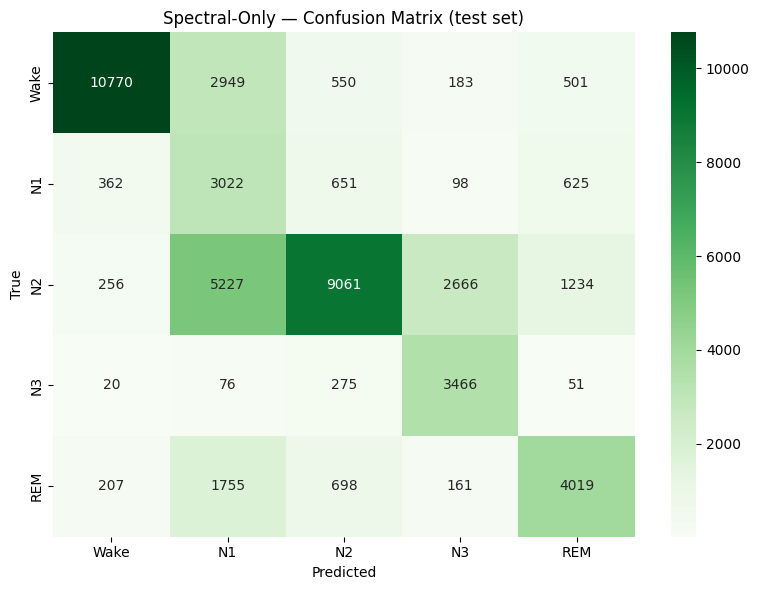

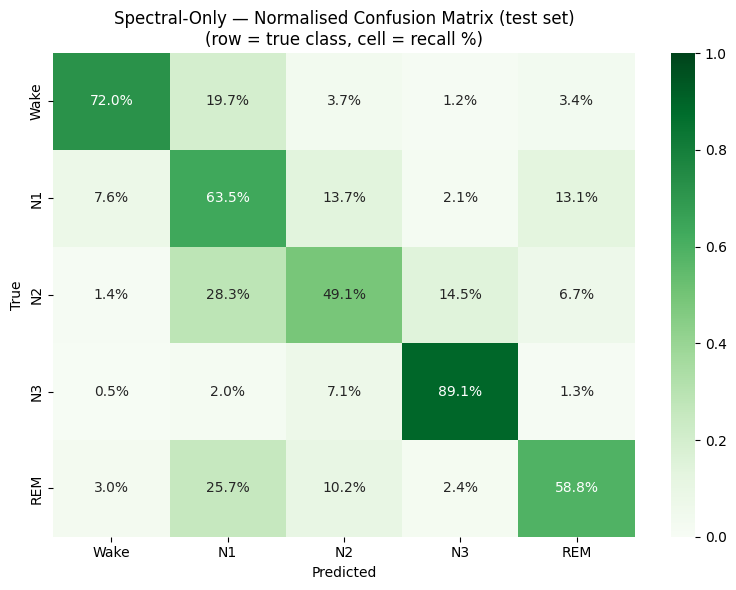

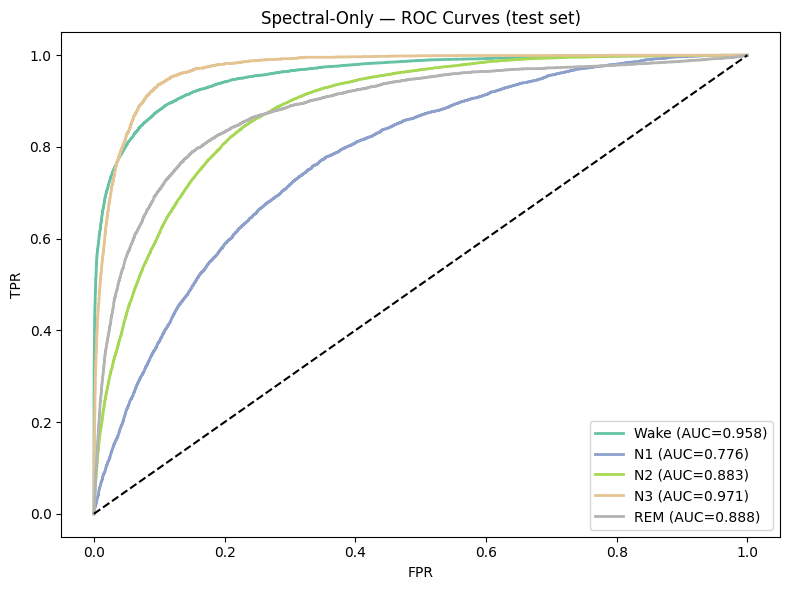

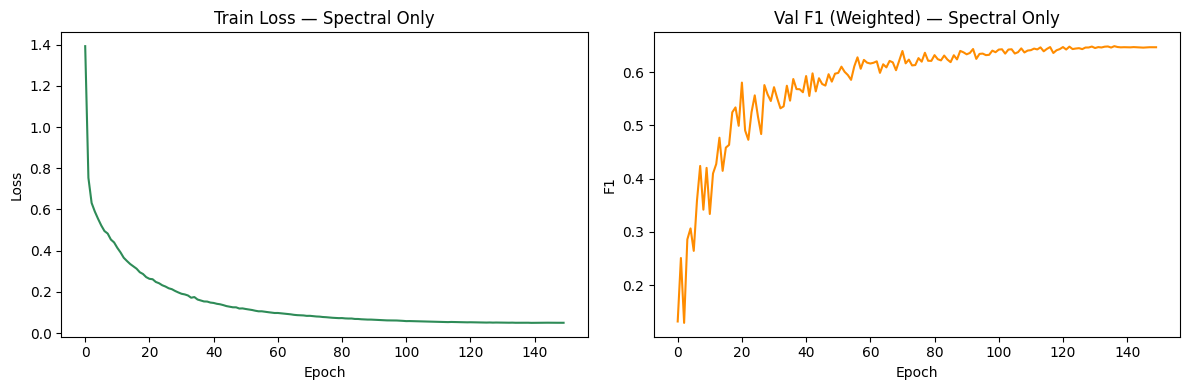


All artefacts saved to: /kaggle/working/evaluation_results_spectral_only


In [10]:
# ── Test-set-only evaluation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path

CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
COLORS      = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
OUTPUT_DIR  = Path('/kaggle/working/evaluation_results_spectral_only')
OUTPUT_DIR.mkdir(exist_ok=True)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
csv_path = '/kaggle/working/output.csv'

torch.cuda.empty_cache()

# ── Recreate the exact same held-out split used during training ───────────────
tmp        = pd.read_csv(csv_path)
indices    = list(range(len(tmp)))
_, val_idx = train_test_split(indices, test_size=0.2, random_state=42)  # same seed

test_dataset = SpectralOnlySleepDataset(
    csv_path,
    file_indices=val_idx,   # only the held-out files
    window_size=256,
    overlap=0
)
# Note: spectral model uses a lightweight MLP encoder so batch_size=16 is fine
# (no large CNN intermediate tensors). Kept at 16 for speed.
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    collate_fn=spectral_collate_fn,
    pin_memory=True,
    persistent_workers=True
)
print(f"Test set: {len(val_idx)} files -> {len(test_dataset):,} chunks")

# ── Load best checkpoint ──────────────────────────────────────────────────────
model = nn.DataParallel(SpectralOnlySleepStagingModel()).to(device)
model.load_state_dict(torch.load('/kaggle/working/best_model_spectral_only.pt', map_location=device))
model.eval()
print("Best spectral-only model loaded!\n")

# ── Inference (AMP on for consistency; MLP is cheap but keeps parity) ─────────
y_true_all, y_pred_all, y_prob_all = [], [], []

with torch.no_grad():
    for x_spec, y, padding_mask in test_loader:
        x_spec       = x_spec.to(device)
        y            = y.to(device)
        padding_mask = padding_mask.to(device)

        with torch.amp.autocast(device_type='cuda'):
            logits, _ = model(x_spec, padding_mask)

        probs = torch.softmax(logits.float(), dim=-1)
        preds = probs.argmax(dim=-1)
        valid = ~padding_mask

        y_true_all.extend(y[valid].cpu().numpy())
        y_pred_all.extend(preds[valid].cpu().numpy())
        y_prob_all.extend(probs[valid].cpu().numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

# ── Classification report ─────────────────────────────────────────────────────
print("\n=== Classification Report — Spectral-Only (held-out test set) ===")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES,
                             zero_division=0))

# ── Raw counts confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Spectral-Only — Confusion Matrix (test set)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_spectral_only_test.png', dpi=150)
plt.show()

# ── Class-normalised confusion matrix (percentages) ───────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0.0, vmax=1.0, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Spectral-Only — Normalised Confusion Matrix (test set)\n(row = true class, cell = recall %)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_spectral_only_test_normalised.png', dpi=150)
plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
y_bin = label_binarize(y_true_all, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Spectral-Only — ROC Curves (test set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_spectral_only_test.png', dpi=150)
plt.show()

# ── Training curve (for reference) ───────────────────────────────────────────
import json as _json
logs      = [_json.loads(l) for l in open('/kaggle/working/training_metrics_spectral_only.jsonl')]
epochs_x  = [d['epoch'] for d in logs]
f1_vals   = [d['f1_weighted'] for d in logs]
loss_vals = [d['train_loss'] for d in logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_x, loss_vals, color='seagreen')
ax1.set_title('Train Loss — Spectral Only'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.plot(epochs_x, f1_vals, color='darkorange')
ax2.set_title('Val F1 (Weighted) — Spectral Only'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_spectral_only.png', dpi=150)
plt.show()

print(f"\nAll artefacts saved to: {OUTPUT_DIR}")


In [11]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=9556fa9630db12269001e264a94713d5ad0bfaa2ad1ee1050af39fec875154df
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=c7f6cca2580e14d297a16168a64ff6e7c69dbc88d4cf582e02832e74f224e55c
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [14]:
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis, parameter_count_table

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Instantiate a clean copy (no DataParallel — tracer doesn't need it) ───────
model_for_count = SpectralOnlySleepStagingModel().to(device)
model_for_count.eval()

# ── Dummy inputs matching actual training shapes ──────────────────────────────
# batch=1, window=256 epochs, 34 spectral features per epoch
dummy_spec = torch.randn(1, 256, 34).to(device)
dummy_mask = torch.zeros(1, 256, dtype=torch.bool).to(device)

# ── FLOPs via fvcore ──────────────────────────────────────────────────────────
flops = FlopCountAnalysis(model_for_count, (dummy_spec, dummy_mask))
flops.unsupported_ops_warnings(False)
flops.uncalled_modules_warnings(False)

total_flops = flops.total()
print(f"[Spectral-Only]  FLOPs : {total_flops:,}")
print(f"[Spectral-Only]  FLOPs : {total_flops / 1e9:.3f}G")

# ── Params directly from PyTorch (ground truth) ───────────────────────────────
total_params     = sum(p.numel() for p in model_for_count.parameters())
trainable_params = sum(p.numel() for p in model_for_count.parameters() if p.requires_grad)
print(f"\n[Spectral-Only]  Total params     : {total_params:,} ({total_params/1e6:.3f}M)")
print(f"[Spectral-Only]  Trainable params : {trainable_params:,} ({trainable_params/1e6:.3f}M)")

# ── Per-module breakdown ──────────────────────────────────────────────────────
print("\n" + parameter_count_table(model_for_count))

# ── Per-module FLOPs breakdown ────────────────────────────────────────────────
print("\nPer-module FLOPs:")
by_module = flops.by_module()
for module_name, count in sorted(by_module.items(), key=lambda x: -x[1]):
    if count > 0 and '.' not in module_name.split('.')[-2:][0]:
        print(f"  {module_name:<45} {count/1e9:.4f}G")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Spectral-Only]  FLOPs : 309,755,904
[Spectral-Only]  FLOPs : 0.310G

[Spectral-Only]  Total params     : 1,211,781 (1.212M)
[Spectral-Only]  Trainable params : 1,211,781 (1.212M)

| name                         | #elements or shape   |
|:-----------------------------|:---------------------|
| model                        | 1.2M                 |
|  spectral_encoder            |  21.5K               |
|   spectral_encoder.0         |   4.5K               |
|    spectral_encoder.0.weight |    (128, 34)         |
|    spectral_encoder.0.bias   |    (128,)            |
|   spectral_encoder.2         |   0.3K               |
|    spectral_encoder.2.weight |    (128,)            |
|    spectral_encoder.2.bias   |    (128,)            |
|   spectral_encoder.3         |   16.5K              |
|    spectral_encoder.3.weight |    (128, 128)        |
|    spectral_encoder.3.bias   |    (128,)            |
|   spectral_encoder.5         |   0.3K               |
|    spectral_encoder.5.weight |   